In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up visualization styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [37]:
def load_events_data(file_path='Agent-sdk_v2/events.json'):
    """
    Load events data from JSON file
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        print(f"✅ Successfully loaded data from {file_path}")
        return data
    except FileNotFoundError:
        print(f"❌ File {file_path} not found!")
        return None
    except json.JSONDecodeError:
        print(f"❌ Invalid JSON format in {file_path}")
        return None

def flatten_events(data):
    """
    Flatten nested event structure into a DataFrame
    """
    flattened_events = []
    
    # Handle both single payload and list of payloads
    if isinstance(data, list):
        payloads = data
    else:
        payloads = [data]
    
    total_events = 0
    for payload in payloads:
        try:
            received_at = payload.get('received_at')
            batch_meta = payload.get('payload', {}).get('batch_meta', {})
            
            # Process each event in the batch
            events = payload.get('payload', {}).get('events', [])
            for event_item in events:
                flat_event = {
                    # Basic metadata
                    'received_at': received_at,
                    'environment': batch_meta.get('environment'),
                    'project': batch_meta.get('project'),
                    'event_count': batch_meta.get('event_count'),
                    'schema_version': batch_meta.get('schema_version'),
                    'sdk_version': batch_meta.get('sdk_version'),
                    
                    # Event details
                    'event_type': event_item.get('event', {}).get('type'),
                    'category': event_item.get('event', {}).get('category'),
                    'severity': event_item.get('event', {}).get('severity'),
                    'status': event_item.get('event', {}).get('status'),
                    'timestamp': event_item.get('meta', {}).get('timestamp'),
                    
                    # Identity info
                    'hostname': event_item.get('identity', {}).get('hostname'),
                    'os': event_item.get('identity', {}).get('os'),
                    'os_version': event_item.get('identity', {}).get('os_version'),
                    'python_version': event_item.get('identity', {}).get('python_version'),
                    'region': event_item.get('identity', {}).get('region'),
                    'app_version': event_item.get('identity', {}).get('app_version'),
                    'instance_id': event_item.get('identity', {}).get('instance_id'),
                    'process_id': event_item.get('identity', {}).get('process_id'),
                    
                    # Trace info
                    'trace_id': event_item.get('meta', {}).get('trace_id'),
                    
                    #data
                    "data": event_item.get('event', {}).get('data', {}),
                    "metrics": event_item.get('event', {}).get('metrics', {})
                }
                
                # Extract data fields based on event type
                event_data = event_item.get('event', {}).get('data', {})
                event_metrics = event_item.get('event', {}).get('metrics', {})
                
                
                # Convert timestamp to datetime
                if flat_event['timestamp']:
                    try:
                        flat_event['timestamp'] = pd.to_datetime(flat_event['timestamp'])
                    except:
                        pass
                
                flattened_events.append(flat_event)
                total_events += 1
                
        except Exception as e:
            print(f"⚠️ Warning: Error processing payload: {e}")
            continue
    
    print(f"✅ Flattened {total_events} events successfully")
    return pd.DataFrame(flattened_events)

In [38]:
data = load_events_data("Agent-sdk_v2/Events_With_Trace.json")
df = flatten_events(data)

✅ Successfully loaded data from Agent-sdk_v2/Events_With_Trace.json
✅ Flattened 8904 events successfully


In [39]:
event_df = df[(df["event_type"] != "SPAN")]

In [40]:
event_df.columns

Index(['received_at', 'environment', 'project', 'event_count',
       'schema_version', 'sdk_version', 'event_type', 'category', 'severity',
       'status', 'timestamp', 'hostname', 'os', 'os_version', 'python_version',
       'region', 'app_version', 'instance_id', 'process_id', 'trace_id',
       'data', 'metrics'],
      dtype='str')

In [41]:
event_collection = event_df['event_type'].unique()

In [42]:
# for event_type in event_collection:
#     print(("=")*40)
#     print(f'event type: {event_type}')
#     print(("=")*40)

#     print(event_df[(event_df['event_type'] == event_type)]['category'].value_counts())
#     print(event_df[(event_df['event_type'] == event_type)]['severity'].value_counts())
#     print(event_df[(event_df['event_type'] == event_type)]['status'].value_counts())
#     print(event_df[(event_df['event_type'] == event_type)]['data'])
#     print(event_df[(event_df['event_type'] == event_type)]['metrics'])


In [43]:
# traces = event_df['trace_id'].unique()
# for trace in traces:
#     print(("=")*40)
#     print(f'trace: {event_type}')
#     print(("=")*40)

#     print(event_df[(event_df['trace_id'] == trace)]['category'].value_counts())
#     print(event_df[(event_df['trace_id'] == trace)]['event_type'].value_counts())
#     print(event_df[(event_df['trace_id'] == trace)]['severity'].value_counts())
#     print(event_df[(event_df['trace_id'] == trace)]['status'].value_counts())
#     print(event_df[(event_df['trace_id'] == trace)]['data'])
#     print(event_df[(event_df['trace_id'] == trace)]['metrics'])

In [44]:
trace_df = event_df[event_df['trace_id'] == 'd9b1c8e5-9c3e-4f0a-8b2e-1a2b3c4d5e6f']

In [45]:
event_df['event_type'].value_counts()

event_type
INCOMING_REQUEST     2075
RESPONSE             2075
REQUEST_VERDICT      2075
TRACE_SUMMARY        2074
REQUEST_EXCEPTION     500
LOG_ERROR              34
HTTP_SLOW_FAILURE      27
LOG_WARNING            26
HTTP_SLOW               7
HTTP_TIMEOUT            6
DB_SUCCESS              2
DB_FAILED               1
HTTP_NOT_FOUND          1
FUNCTION_SLOW           1
Name: count, dtype: int64

In [46]:
event_df['trace_id'].unique()

<StringArray>
['4ed5836a-b30a-49a2-b4e0-9d4b2e0a924e',
 '5b68eeef-d339-4bdb-9b10-5e4d952a3ab1',
 'b35af72a-c482-479f-9af9-a7db22053133',
 '4a50c073-edda-4635-b41c-b83fc3773fad',
 '9f59de24-56c9-4c5d-a852-5988fdc604f7',
 '495b0180-9190-478d-a44b-4d7f3ba9641a',
 'e1de2400-1bb8-4d5d-9715-1973779f5514',
 '6c3bd724-fcf7-49cc-8e2a-a97bea9cd666',
 '2269cc28-6217-4493-907b-0450546cf6f3',
 '724bef37-09ee-4206-b60e-075bf5e309a1',
 ...
 'dfad299e-f8b9-4c47-a7f4-8ae24f3585bb',
 '889cdc4d-7f03-4846-835d-20daa94e2ee2',
 'cc67c6ac-8d53-4f4d-ab4f-92da5cc9ded3',
 '7f3b3f8b-610c-4327-bb8a-6807cc55c4fd',
 'a545224f-bfc8-4bb5-ab5d-8c144eef21ce',
 '191473a4-8963-43af-a63a-70aeec9d913c',
 'afbd7255-6040-4ae1-bfe5-347609f9b887',
 '6f348c10-57c7-46b9-a1da-da78f6f86a8c',
 'a4ed09e5-56b6-48ff-b125-0b5ae91e9d9c',
 '98f39587-1faa-4802-a202-b8b49e53210b']
Length: 2075, dtype: str

In [47]:
event_df[(event_df['event_type'] == "TRACE_SUMMARY")]['data'].iloc[0]

{'event_flow': ['INCOMING_REQUEST', 'RESPONSE'],
 'event_ids': ['f00fa430-4d1c-49a7-9333-bd786a732921',
  '2e6ef6eb-6bca-43cb-bece-047713c4a796',
  'cb11ec41-f927-4d35-ab47-553867cc1376'],
 'intelligence': {'explanation': 'request response generated successfully without any issues',
  'impact': 'Request completed successfully without significant issues',
  'outcome': 'SUCCESS',
  'root_cause': None},
 'outcome': 'SUCCESS',
 'root_cause': None,
 'root_span_id': 'd4782b3a-7062-4c07-9d1e-1daf22da61ca',
 'spans': {'d4782b3a-7062-4c07-9d1e-1daf22da61ca': {'child_span_ids': [],
   'duration_ms': 11.357,
   'event_flow': ['INCOMING_REQUEST', 'RESPONSE'],
   'event_ids': ['f00fa430-4d1c-49a7-9333-bd786a732921',
    '2e6ef6eb-6bca-43cb-bece-047713c4a796',
    'cb11ec41-f927-4d35-ab47-553867cc1376'],
   'extra': {'classification': 'REQUEST_SUCCESS_FAST',
    'duration_ms': 11,
    'exception_type': None,
    'method': 'GET',
    'path': '/http/200',
    'status_code': 200},
   'outcome': 'SUCCES

In [48]:
trace_summary_data = event_df[(event_df['event_type'] == "TRACE_SUMMARY")]['data']

In [49]:

all_rows = []

for trace in trace_summary_data:
    root_span = trace["spans"][trace["root_span_id"]]
    event_flow = root_span.get("event_flow", [])
    extra = root_span.get("extra", {})

    status_code = extra.get("status_code", 0)
    duration = root_span.get("duration_ms", 0)

    row = {
        # 🔹 IDs
        "trace_id": trace.get("trace_id"),

        # 🔹 Target
        "trace_outcome": trace.get("outcome"),

        # 🔹 Optional (analysis only)
        "intel_outcome": trace.get("intelligence", {}).get("outcome"),

        # 🔹 Core Features
        "status_code": status_code,
        "duration_ms": duration,

        # 🔹 Derived HTTP features
        "is_server_error": int(status_code >= 500),
        "is_client_error": int(400 <= status_code < 500),

        # 🔹 Performance
        "is_slow": int(duration > 1000) if duration else False,  # tune threshold

        # 🔹 Event Flow Features
        "event_count": len(event_flow),
        "has_timeout": int("HTTP_TIMEOUT" in event_flow),
        "has_exception_event": int("REQUEST_EXCEPTION" in event_flow),
        "has_response": int("RESPONSE" in event_flow),

        # 🔹 Last event (important)
        "last_event": event_flow[-1] if event_flow else None,

        # 🔹 Classification
        "classification": extra.get("classification"),

        # 🔹 Exception
        "has_exception": int(extra.get("exception_type") is not None),
    }

    all_rows.append(row)

trace_summary_df = pd.DataFrame(all_rows)

In [50]:
trace_summary_df

,trace_id,trace_outcome,intel_outcome,status_code,duration_ms,is_server_error,is_client_error,is_slow,event_count,has_timeout,has_exception_event,has_response,last_event,classification,has_exception
0,4ed5836a-b30a-49a2-b4e0-9d4b2e0a924e,SUCCESS,SUCCESS,200,11.357,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
1,5b68eeef-d339-4bdb-9b10-5e4d952a3ab1,SUCCESS,SUCCESS,404,20.147,0,1,0,2,0,0,1,RESPONSE,REQUEST_FAILED_ROUTING,0
2,b35af72a-c482-479f-9af9-a7db22053133,SUCCESS,SUCCESS,403,20.469,0,1,0,2,0,0,1,RESPONSE,REQUEST_FAILED_CLIENT,0
3,4a50c073-edda-4635-b41c-b83fc3773fad,SUCCESS,SUCCESS,200,23.757,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
4,9f59de24-56c9-4c5d-a852-5988fdc604f7,SUCCESS,SUCCESS,200,20.271,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069,191473a4-8963-43af-a63a-70aeec9d913c,SUCCESS,SUCCESS,200,1.116,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
2070,afbd7255-6040-4ae1-bfe5-347609f9b887,SUCCESS,SUCCESS,200,0.750,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
2071,6f348c10-57c7-46b9-a1da-da78f6f86a8c,FAILED,FAILED,500,0.891,1,0,0,3,0,1,1,RESPONSE,REQUEST_FAILED_SERVER,0
2072,98f39587-1faa-4802-a202-b8b49e53210b,SUCCESS,SUCCESS,200,1.065,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0


In [51]:
trace_summary_df['trace_outcome'].value_counts(),

(trace_outcome
 SUCCESS     1470
 FAILED       525
 DEGRADED      33
 CRITICAL       6
 Name: count, dtype: int64,)

In [52]:
trace_summary_df['status_code'].value_counts()

status_code
200    1201
500     501
401     145
404      61
0        40
403      31
504      30
405      27
400      26
429       4
302       4
307       4
Name: count, dtype: int64

In [53]:
import plotly.express as px

plt = px.histogram(trace_summary_df, x='status_code', color='trace_outcome', title='Distribution of Status Codes by Trace Outcome')
plt.show()

In [54]:
px.scatter(trace_summary_df, x='duration_ms', y='status_code', color='trace_outcome', title='Duration vs Status Code by Trace Outcome')

In [55]:
plt = px.histogram(trace_summary_df, x='classification', color='trace_outcome', title='Distribution of Classifications by Trace Outcome')
plt.show()

In [56]:
event_signal_df = event_df[(event_df['event_type'] != "TRACE_SUMMARY")]

In [57]:
event_signal_df.head(3)

,received_at,environment,project,event_count,schema_version,sdk_version,event_type,category,severity,status,...,os,os_version,python_version,region,app_version,instance_id,process_id,trace_id,data,metrics
0,2026-03-30T14:15:21.326366,production,Online_website_logs,8,1.0,2.0.0,INCOMING_REQUEST,APPLICATION,LOW,STARTED,...,Windows,11,3.13.4,unknown,1.0.0,8ed293ae-de5d-458a-a980-ad5fa32eb63d,4328,4ed5836a-b30a-49a2-b4e0-9d4b2e0a924e,"{'client_ip': '127.0.0.1', 'method': 'GET', 'p...","{'duration_ms': 0.739, 'duration_us': 739}"
1,2026-03-30T14:15:21.326366,production,Online_website_logs,8,1.0,2.0.0,RESPONSE,APPLICATION,LOW,SUCCESS,...,Windows,11,3.13.4,unknown,1.0.0,8ed293ae-de5d-458a-a980-ad5fa32eb63d,4328,4ed5836a-b30a-49a2-b4e0-9d4b2e0a924e,"{'client_ip': '127.0.0.1', 'method': 'GET', 'p...","{'duration_ms': 10.906, 'duration_us': 10906}"
2,2026-03-30T14:15:21.326366,production,Online_website_logs,8,1.0,2.0.0,REQUEST_VERDICT,FINAL,LOW,SUCCESS,...,Windows,11,3.13.4,unknown,1.0.0,8ed293ae-de5d-458a-a980-ad5fa32eb63d,4328,4ed5836a-b30a-49a2-b4e0-9d4b2e0a924e,"{'classification': 'REQUEST_SUCCESS_FAST', 'ex...","{'duration_ms': 11.332, 'duration_us': 11331, ..."


## index columns
       Index(['received_at', 'environment', 'project', 'event_count',
       'schema_version', 'sdk_version', 'event_type', 'category', 'severity',
       'status', 'timestamp', 'hostname', 'os', 'os_version', 'python_version',
       'region', 'app_version', 'instance_id', 'process_id', 'trace_id',
       'data', 'metrics'],
       dtype='str')

In [58]:
event_signal_df["duration_ms"] = event_signal_df["metrics"].apply(lambda x: x.get("duration_ms") if isinstance(x, dict) else None)

event_signal_df["status_code"] = event_signal_df["data"].apply(lambda x: x.get("status_code") if isinstance(x, dict) else None)

event_signal_df["path"] = event_signal_df["data"].apply(lambda x: x.get("path") if isinstance(x, dict) else None)

In [59]:
trace_event_signal_df = event_signal_df.groupby("trace_id").agg({
    "event_type": list,
    "duration_ms": "sum",
    "status_code": "max",
    "received_at": "first"
}).reset_index()

trace_event_signal_df.rename(columns={"event_type": "event_flow"}, inplace=True)

In [60]:
trace_event_signal_df["has_exception"] = trace_event_signal_df["event_flow"].apply(
    lambda x: any("EXCEPTION" in e for e in x)
)

trace_event_signal_df["has_error"] = trace_event_signal_df["event_flow"].apply(
    lambda x: any("FAILED" in e or "ERROR" in e for e in x)
)

trace_event_signal_df["has_slow"] = trace_event_signal_df["event_flow"].apply(
    lambda x: any("SLOW" in e for e in x)
)

trace_event_signal_df["has_timeout"] = trace_event_signal_df["event_flow"].apply(
    lambda x: any("TIMEOUT" in e for e in x)
)

In [61]:
def signal_truth(row):
    if row["has_timeout"]:
        return "CRITICAL"
    if row["has_exception"] or row["has_error"]:
        return "FAILED"
    if row["has_slow"]:
        return "DEGRADED"
    return "SUCCESS"

trace_event_signal_df["signal_outcome"] = trace_event_signal_df.apply(signal_truth, axis=1)

In [62]:
trace_event_signal_df["signal_outcome"].value_counts()

signal_outcome
SUCCESS     1500
FAILED       534
DEGRADED      35
CRITICAL       6
Name: count, dtype: int64

In [63]:
final_df = pd.merge(trace_event_signal_df, trace_summary_df, on='trace_id')


In [64]:
final_df.head(5)

,trace_id,event_flow,duration_ms_x,status_code_x,received_at,has_exception_x,has_error,has_slow,has_timeout_x,signal_outcome,...,is_server_error,is_client_error,is_slow,event_count,has_timeout_y,has_exception_event,has_response,last_event,classification,has_exception_y
0,001d1088-ced7-4ec5-b8f7-729a11f5fb8e,"[INCOMING_REQUEST, RESPONSE, REQUEST_VERDICT]",2.561,200.0,2026-03-30T22:05:05.316333,False,False,False,False,SUCCESS,...,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
1,002a5d78-ebbc-46df-9c7f-a49443a7eca1,"[INCOMING_REQUEST, RESPONSE, REQUEST_VERDICT]",1.953,200.0,2026-03-30T22:08:15.443707,False,False,False,False,SUCCESS,...,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
2,0059b9e5-6031-47e9-82e7-232aec94b79d,"[INCOMING_REQUEST, REQUEST_EXCEPTION, RESPONSE...",4.238,500.0,2026-03-30T22:06:55.672139,True,False,False,False,FAILED,...,1,0,0,3,0,1,1,RESPONSE,REQUEST_FAILED_SERVER,0
3,00715456-af53-4143-8742-f58bcf536a33,"[INCOMING_REQUEST, RESPONSE, REQUEST_VERDICT]",3.504,200.0,2026-03-30T21:59:44.140073,False,False,False,False,SUCCESS,...,0,0,0,2,0,0,1,RESPONSE,REQUEST_SUCCESS_FAST,0
4,00c04b0d-4a86-4abf-9daf-a7273131ebd0,"[INCOMING_REQUEST, REQUEST_EXCEPTION, RESPONSE...",2.701,500.0,2026-03-30T22:08:49.676021,True,False,False,False,FAILED,...,1,0,0,3,0,1,1,RESPONSE,REQUEST_FAILED_SERVER,0


In [65]:
final_df[(final_df['signal_outcome'] != final_df['trace_outcome'])]['signal_outcome'].value_counts()

signal_outcome
FAILED      36
SUCCESS     30
DEGRADED    27
Name: count, dtype: int64

In [66]:
final_df[final_df['signal_outcome'] != final_df['trace_outcome']] \
    [['signal_outcome', 'trace_outcome']] \
    .value_counts()

signal_outcome  trace_outcome
DEGRADED        FAILED           27
SUCCESS         DEGRADED         26
Name: count, dtype: int64

In [67]:
accuracy = (final_df['signal_outcome'] == final_df['trace_outcome']).mean()
accuracy

np.float64(0.9551591128254581)

In [68]:
mapping = {
    'SUCCESS': 0,
    'DEGRADED': 1,
    'FAILED': 2,
    'CRITICAL': 3
}

final_df['signal_outcome_encoded'] = final_df['signal_outcome'].map(mapping)
final_df['trace_outcome_encoded'] = final_df['trace_outcome'].map(mapping)

In [69]:
final_df['error_severity_gap'] = (
    final_df['signal_outcome_encoded'] - final_df['trace_outcome_encoded']
)

In [70]:
final_df['error_severity_gap'].value_counts()

error_severity_gap
 0.0    1981
-1.0      53
Name: count, dtype: int64

In [71]:
final_df.dropna(subset=['signal_outcome_encoded', 'trace_outcome_encoded'], inplace=True)

In [72]:
final_df[final_df['error_severity_gap'] == -1][
    ['signal_outcome', 'trace_outcome']
].value_counts()

signal_outcome  trace_outcome
DEGRADED        FAILED           27
SUCCESS         DEGRADED         26
Name: count, dtype: int64

In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    final_df['signal_outcome_encoded'],
    final_df['trace_outcome_encoded']
)
print(cm)

[[1470   26    0    0]
 [   0    7   27    0]
 [   0    0  498    0]
 [   0    0    0    6]]


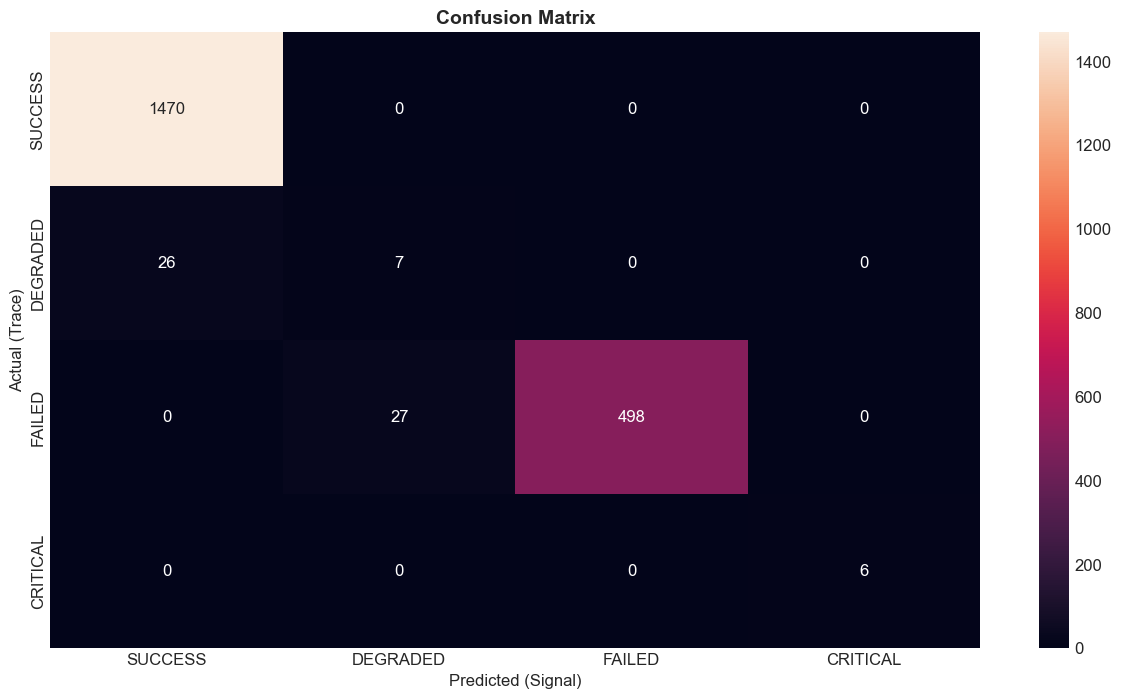

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ['SUCCESS', 'DEGRADED', 'FAILED', 'CRITICAL']

cm = confusion_matrix(
    final_df['trace_outcome'],
    final_df['signal_outcome'],
    labels=labels
)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted (Signal)")
plt.ylabel("Actual (Trace)")
plt.title("Confusion Matrix")

plt.show()



In [75]:
from sklearn.metrics import classification_report

labels = ['SUCCESS', 'DEGRADED', 'FAILED', 'CRITICAL']

report = classification_report(
    final_df['trace_outcome'],     # actual
    final_df['signal_outcome'],    # predicted
    labels=labels
)

print(report)

              precision    recall  f1-score   support

     SUCCESS       0.98      1.00      0.99      1470
    DEGRADED       0.21      0.21      0.21        33
      FAILED       1.00      0.95      0.97       525
    CRITICAL       1.00      1.00      1.00         6

    accuracy                           0.97      2034
   macro avg       0.80      0.79      0.79      2034
weighted avg       0.97      0.97      0.97      2034



In [76]:
final_df['event_flow_str'] = final_df['event_flow'].astype(str)

In [77]:
final_df['event_count'] = final_df['event_flow'].apply(len)

In [78]:
final_df['has_timeout_event'] = final_df['event_flow'].apply(
    lambda x: 'HTTP_TIMEOUT' in x
)

final_df['has_error_event'] = final_df['event_flow'].apply(
    lambda x: 'REQUEST_EXCEPTION' in x
)

In [79]:
final_df['last_event'] = final_df['event_flow'].apply(lambda x: x[-1])

In [80]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()

final_df['classification_encoded'] = le1.fit_transform(final_df['classification'])

le2 = LabelEncoder()
final_df['event_flow_encoded'] = le2.fit_transform(final_df['event_flow_str'])

le3 = LabelEncoder()
final_df['last_event_encoded'] = le3.fit_transform(final_df['last_event'])

In [81]:
def is_failed_pattern(flow):
    return 'HTTP_TIMEOUT' in flow or 'REQUEST_EXCEPTION' in flow

final_df['failed_pattern'] = final_df['event_flow'].apply(is_failed_pattern)

In [82]:
features = [
    'duration_ms_x',
    'status_code_x',
    'has_exception_x',
    'has_error',
    'has_slow',
    'has_timeout_x',
    'classification_encoded',
    'event_count',
    'has_timeout_event',
    'has_error_event',
    'last_event_encoded',
    'event_flow_encoded',
]

target = 'signal_outcome_encoded'

In [83]:
from sklearn.model_selection import train_test_split

X = final_df[features]
y = final_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # IMPORTANT for your case
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [85]:
y_pred = model.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [87]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        93
           3       1.00      1.00      1.00         1

    accuracy                           1.00       407
   macro avg       1.00      1.00      1.00       407
weighted avg       1.00      1.00      1.00       407



In [88]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[306   0   0   0]
 [  0   7   0   0]
 [  0   0  93   0]
 [  0   0   0   1]]


In [89]:
all_rows = []

for trace in trace_summary_data:
    root_span = trace["spans"][trace["root_span_id"]]
    event_flow = root_span.get("event_flow", [])
    extra = root_span.get("extra", {})

    status_code = extra.get("status_code", 0)
    duration = root_span.get("duration_ms", 0)

    row = {
        # 🔹 IDs
        "trace_id": trace.get("trace_id"),

        # 🔹 Target
        "trace_outcome": trace.get("outcome"),

        # 🔹 Optional (analysis only)
        "intel_outcome": trace.get("intelligence", {}).get("outcome"),

        # 🔹 Core Features
        "status_code": status_code,
        "duration_ms": duration,

        # 🔹 Derived HTTP features
        "is_server_error": int(status_code >= 500),
        "is_client_error": int(400 <= status_code < 500),

        # 🔹 Performance
        "is_slow": int(duration > 1000) if duration else False,  # tune threshold

        # 🔹 Event Flow Features
        "event_count": len(event_flow),
        "has_timeout": int("HTTP_TIMEOUT" in event_flow),
        "has_exception_event": int("REQUEST_EXCEPTION" in event_flow),
        "has_response": int("RESPONSE" in event_flow),

        # 🔹 Last event (important)
        "last_event": event_flow[-1] if event_flow else None,

        # 🔹 Classification
        "classification": extra.get("classification"),

        # 🔹 Exception
        "has_exception": int(extra.get("exception_type") is not None),
    }

    all_rows.append(row)

trace_summary_df = pd.DataFrame(all_rows)

In [90]:
trace_summary_df.dropna(subset=['trace_outcome'], inplace=True)

In [91]:
from sklearn.preprocessing import LabelEncoder

le_event = LabelEncoder()
le_class = LabelEncoder()

trace_summary_df['last_event_encoded'] = le_event.fit_transform(
    trace_summary_df['last_event'].astype(str)
)

trace_summary_df['classification_encoded'] = le_class.fit_transform(
    trace_summary_df['classification'].astype(str)
)


In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [93]:
le_target = LabelEncoder()

trace_summary_df['trace_outcome_encoded'] = le_target.fit_transform(
    trace_summary_df['trace_outcome']
)

In [94]:
le_target.classes_

array(['CRITICAL', 'DEGRADED', 'FAILED', 'SUCCESS'], dtype=object)

In [ ]:
le_event = LabelEncoder()
le_class = LabelEncoder()

trace_summary_df['last_event_encoded'] = le_event.fit_transform(
    trace_summary_df['last_event'].astype(str)
)

trace_summary_df['classification_encoded'] = le_class.fit_transform(
    trace_summary_df['classification'].astype(str)
)

In [ ]:
features = [
    'status_code',
    'duration_ms',
    'is_server_error',
    'is_client_error',
    'is_slow',
    'event_count',
    'has_timeout',
    'has_exception_event',
    'has_response',
    'last_event_encoded',
    'classification_encoded',
    'has_exception'
]

X = trace_summary_df[features]
y = trace_summary_df['trace_outcome_encoded']

In [95]:
from sklearn.utils import shuffle

X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_shuffled, y_shuffled, test_size=0.4, random_state=42, stratify=y_shuffled
)



In [96]:
model = RandomForestClassifier(
    n_estimators=1200,
   class_weight = {
    0: 30,   # (if exists)
    1: 10,   # 🔥 DEGRADED (increase a lot)
    2: 5,   # FAILED (medium)
    3: 1,   # SUCCESS (major class)
},
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [97]:
y_pred = model.predict(X_test)

In [98]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9987714987714987


In [99]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[598   1   0   0]
 [  0  14   0   0]
 [  0   0 199   0]
 [  0   0   0   2]]


In [100]:
import pandas as pd

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

                   feature  importance
2          has_exception_x    0.255110
9          has_error_event    0.247801
11      event_flow_encoded    0.158172
7              event_count    0.122283
1            status_code_x    0.098386
0            duration_ms_x    0.040267
4                 has_slow    0.036626
6   classification_encoded    0.031580
3                has_error    0.008798
5            has_timeout_x    0.000493
8        has_timeout_event    0.000485
10      last_event_encoded    0.000000


In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       599
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00       199
           3       1.00      1.00      1.00         2

    accuracy                           1.00       814
   macro avg       0.98      1.00      0.99       814
weighted avg       1.00      1.00      1.00       814



In [102]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())

CV Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


In [103]:
final_df['is_anomaly'] = (
    final_df['signal_outcome'] != final_df['trace_outcome']
)

In [104]:
final_df['is_anomaly'].value_counts()

is_anomaly
False    1981
True       53
Name: count, dtype: int64

In [105]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

anomaly_pred = model.fit_predict(X)

In [106]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)

anomaly_pred = lof.fit_predict(X)

In [ ]:
final_df.head(3)

,trace_id,event_flow,duration_ms_x,status_code_x,received_at,has_exception_x,has_error,has_slow,has_timeout_x,signal_outcome,...,trace_outcome_encoded,error_severity_gap,event_flow_str,has_timeout_event,has_error_event,classification_encoded,event_flow_encoded,last_event_encoded,failed_pattern,is_anomaly
0,001d1088-ced7-4ec5-b8f7-729a11f5fb8e,"[INCOMING_REQUEST, RESPONSE, REQUEST_VERDICT]",2.561,200.0,2026-03-30T22:05:05.316333,False,False,False,False,SUCCESS,...,0.0,0.0,"['INCOMING_REQUEST', 'RESPONSE', 'REQUEST_VERD...",False,False,4,9,0,False,False
1,002a5d78-ebbc-46df-9c7f-a49443a7eca1,"[INCOMING_REQUEST, RESPONSE, REQUEST_VERDICT]",1.953,200.0,2026-03-30T22:08:15.443707,False,False,False,False,SUCCESS,...,0.0,0.0,"['INCOMING_REQUEST', 'RESPONSE', 'REQUEST_VERD...",False,False,4,9,0,False,False
2,0059b9e5-6031-47e9-82e7-232aec94b79d,"[INCOMING_REQUEST, REQUEST_EXCEPTION, RESPONSE...",4.238,500.0,2026-03-30T22:06:55.672139,True,False,False,False,FAILED,...,2.0,0.0,"['INCOMING_REQUEST', 'REQUEST_EXCEPTION', 'RES...",False,True,2,8,0,True,False


In [107]:
final_df['rule_anomaly'] = (
    final_df['signal_outcome'] != final_df['trace_outcome']
).astype(int)

In [127]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    'status_code_x',
    'duration_ms_x',
    'event_count',
    'has_timeout_x',
    'has_exception_x',
    'is_server_error'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(final_df[anomaly_features])

iso_model = IsolationForest(
    n_estimators=1000,
    contamination=0.2,
    random_state=42
)

final_df['is_server_error'] = (final_df['status_code_x'] >= 500).astype(int)

pred = iso_model.fit_predict(scaled_features)
print(len(pred))

final_df['ml_anomaly'] =pred


# final_df['ml_anomaly'] = iso_model.fit_predict(final_df[anomaly_features])

# Convert: -1 → anomaly, 1 → normal
final_df['ml_anomaly'] = final_df['ml_anomaly'].map({1: 0, -1: 1})

2034


In [128]:
final_df['ml_anomaly'].value_counts(), final_df['rule_anomaly'].value_counts()

(ml_anomaly
 0    1627
 1     407
 Name: count, dtype: int64,
 rule_anomaly
 0    1981
 1      53
 Name: count, dtype: int64)

In [109]:
final_df['anomaly_score'] = (
    final_df['ml_anomaly'] * 0.6 +
    final_df['rule_anomaly'] * 0.4
)

In [110]:
final_df['final_anomaly'] = (final_df['anomaly_score'] > 0.5).astype(int)

In [ ]:
def classify_anomaly(row):
    if row['rule_anomaly'] == 1 and row['ml_anomaly'] == 1:
        return "CRITICAL"
    elif row['rule_anomaly'] == 1:
        return "LOGIC_MISMATCH"
    elif row['ml_anomaly'] == 1:
        return "BEHAVIOR_ANOMALY"
    else:
        return "NORMAL"

final_df['anomaly_type'] = final_df.apply(classify_anomaly, axis=1)

In [ ]:
print(final_df['anomaly_type'].value_counts())

anomaly_type
NORMAL            1981
LOGIC_MISMATCH      53
Name: count, dtype: int64


In [ ]:
anom = final_df[final_df['anomaly_type'] == 'LOGIC_MISMATCH']

In [ ]:
anom[['signal_outcome', 'trace_outcome']].value_counts()

signal_outcome  trace_outcome
DEGRADED        FAILED           27
SUCCESS         DEGRADED         26
Name: count, dtype: int64

In [ ]:
final_df['final_anomaly'] = (
    (final_df['rule_anomaly'] == 1) |
    (final_df['ml_anomaly'] == 1)
).astype(int)